## Task: Review one paragraph from 3 angles in parallel:

In [1]:
# Run this only if packages are not installed
# !pip install langgraph langchain-openai typing_extensions

In [3]:
import os
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
from langchain_openai import ChatOpenAI

import getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("OPENAI_API_KEY")

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [4]:
class State(TypedDict):
    content: str
    clarity_feedback: str
    accuracy_feedback: str
    example_feedback: str
    final_review: str

Node 1: Clarity reviewer

In [5]:
def clarity_reviewer(state: State):
    prompt = f"""
Review the following content only for clarity.

Check:
- Is it easy to understand?
- Are the sentences simple?
- Is the explanation beginner-friendly?

Content:
{state["content"]}

Return short feedback.
"""
    response = llm.invoke(prompt)
    return {"clarity_feedback": response.content}

Node 1: Accuracy reviewer

In [6]:
def accuracy_reviewer(state: State):
    prompt = f"""
Review the following content only for technical accuracy.

Check:
- Are the facts correct?
- Is anything misleading?
- Is the explanation technically sound?

Content:
{state["content"]}

Return short feedback.
"""
    response = llm.invoke(prompt)
    return {"accuracy_feedback": response.content}

Node 3: Example reviewer

In [7]:
def example_reviewer(state: State):
    prompt = f"""
Review the following content only for example quality.

Check:
- Is there a useful example?
- Does the example match the topic?
- Would a beginner understand the example?

Content:
{state["content"]}

Return short feedback.
"""
    response = llm.invoke(prompt)
    return {"example_feedback": response.content}

Join Node: Final review

In [8]:
def final_review_node(state: State):
    prompt = f"""
Create a final combined review using the three feedback reports.

Original Content:
{state["content"]}

Clarity Feedback:
{state["clarity_feedback"]}

Accuracy Feedback:
{state["accuracy_feedback"]}

Example Feedback:
{state["example_feedback"]}

Return:
1. Overall review
2. Main problems
3. Improved version of the content
"""
    response = llm.invoke(prompt)
    return {"final_review": response.content}

Build the Parallel LangGraph Workflow

In [9]:
workflow = StateGraph(State)

workflow.add_node("clarity_reviewer", clarity_reviewer)
workflow.add_node("accuracy_reviewer", accuracy_reviewer)
workflow.add_node("example_reviewer", example_reviewer)
workflow.add_node("final_review_node", final_review_node)

# Start three branches in parallel
workflow.add_edge(START, "clarity_reviewer")
workflow.add_edge(START, "accuracy_reviewer")
workflow.add_edge(START, "example_reviewer")

# Join all three branches into final review node
workflow.add_edge("clarity_reviewer", "final_review_node")
workflow.add_edge("accuracy_reviewer", "final_review_node")
workflow.add_edge("example_reviewer", "final_review_node")

workflow.add_edge("final_review_node", END)

chain = workflow.compile()

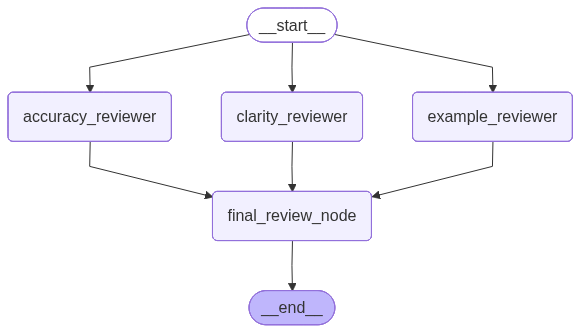

In [10]:
display(Image(chain.get_graph().draw_mermaid_png()))

In [11]:
input_state = {
    "content": """
LangGraph is a library used to create AI workflows. 
It allows different steps to connect with each other. 
For example, one step can generate an answer and another step can check it.
"""
}

result = chain.invoke(input_state)

print("CLARITY FEEDBACK")
print("=" * 80)
print(result["clarity_feedback"])

print("\nACCURACY FEEDBACK")
print("=" * 80)
print(result["accuracy_feedback"])

print("\nEXAMPLE FEEDBACK")
print("=" * 80)
print(result["example_feedback"])

print("\nFINAL REVIEW")
print("=" * 80)
print(result["final_review"])

CLARITY FEEDBACK
The content is clear and easy to understand. The sentences are simple and straightforward, making it beginner-friendly. The example effectively illustrates how the steps in LangGraph connect, enhancing comprehension. Overall, it communicates the main idea well.

ACCURACY FEEDBACK
The content is generally accurate in describing LangGraph as a library for creating AI workflows that connect different steps. However, it could benefit from more specific details about how these connections are made and the types of steps involved. The example provided is somewhat vague; it would be clearer to specify what kind of answer is generated and how the checking process works. Overall, the explanation is technically sound but could be enhanced with more precise information.

EXAMPLE FEEDBACK
The example provided is useful and matches the topic of LangGraph as it illustrates how different steps in AI workflows can interact. However, it could be clearer for a beginner. Expanding on wha